#بخش اول،پیاده سازی معیار های اندازه گیری ارتباط عملکردی مغز

#همبستگی
Correlation vs. Delay

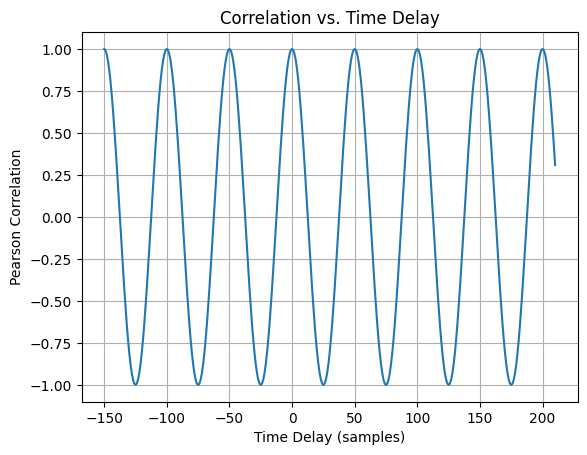

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.signal import correlate

def my_corr(x, y):
    return np.corrcoef(x, y)[0, 1]


fs = 500
t = np.linspace(0, 1, fs, endpoint=False)
f = 10


x = np.sin(2 * np.pi * f * t)
correlations = []
delays = np.arange(-150, 211)

for t0 in delays / fs:
    y = np.sin(2 * np.pi * f * (t - t0))
    correlations.append(my_corr(x, y))

plt.plot(delays, correlations)
plt.xlabel("Time Delay (samples)")
plt.ylabel("Pearson Correlation")
plt.title("Correlation vs. Time Delay")
plt.grid(True)
plt.show()


SNR effect on correlation , and an example

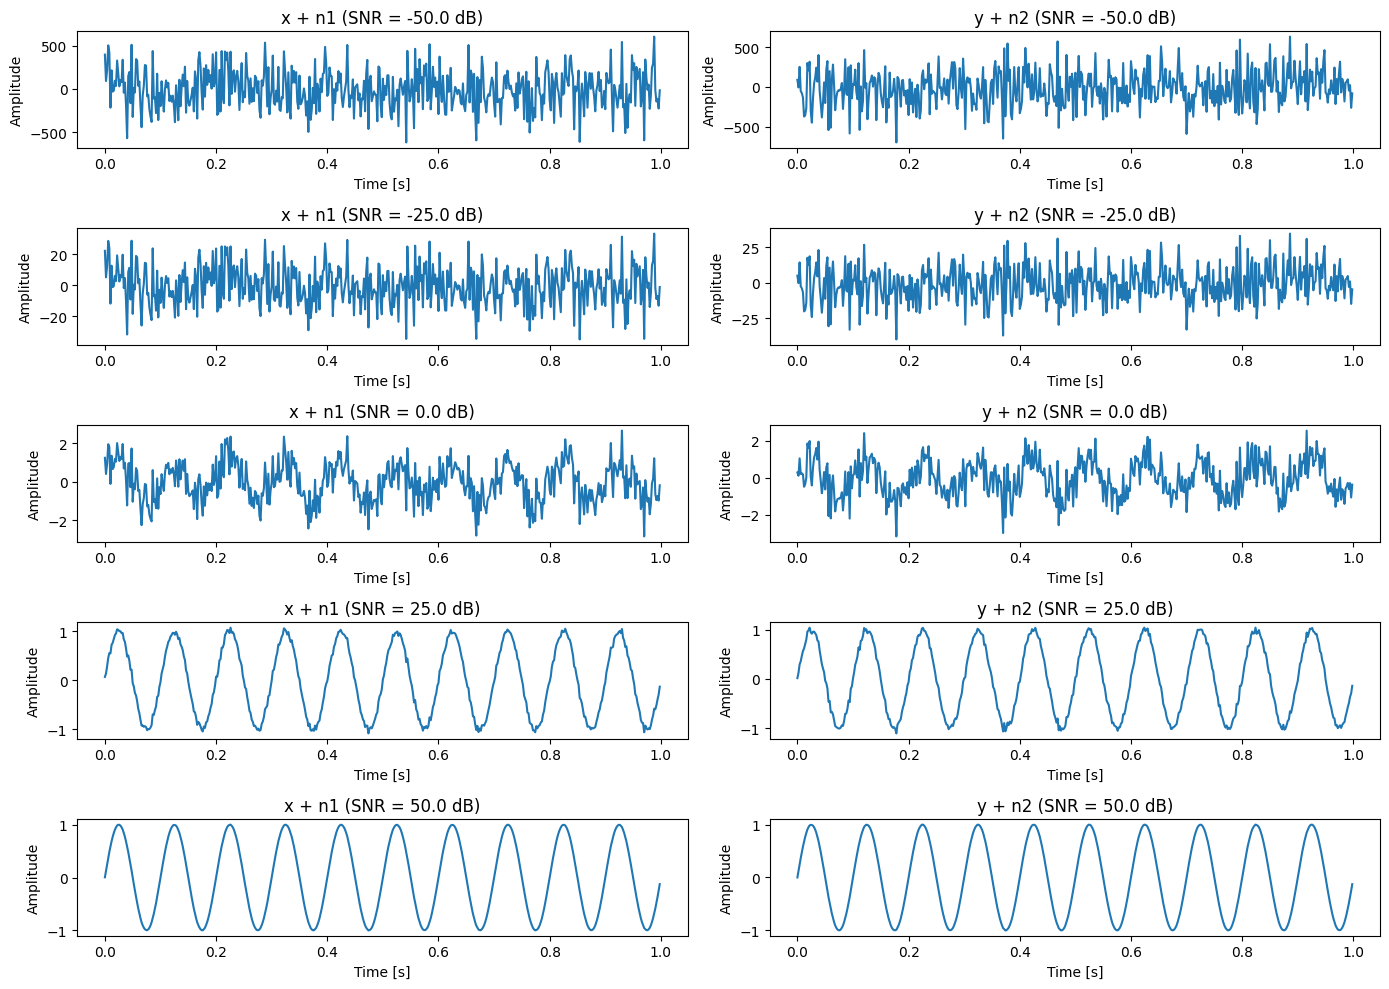

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 500
t = np.linspace(0, 1, fs, endpoint=False)
f = 10

# Define two signals
x = np.sin(2 * np.pi * f * t)
y = np.sin(2 * np.pi * f * (t - 0.1))  # delayed version of x

# Compute clean signal powers
P_x = np.mean(x ** 2)
P_y = np.mean(y ** 2)

# Generate two independent Gaussian noise signals
np.random.seed(0)
n1 = np.random.normal(0, 1, len(t))
n2 = np.random.normal(0, 1, len(t))

P_n1 = np.mean(n1 ** 2)
P_n2 = np.mean(n2 ** 2)

# SNR values to test
snr_dB_values = np.linspace(-50, 50, 5)

# Plotting results
plt.figure(figsize=(14, 10))

for i, snr_db in enumerate(snr_dB_values):
    snr_linear = 10 ** (snr_db / 10)

    # Scale noise to achieve target SNR
    scale_n1 = np.sqrt(P_x / (P_n1 * snr_linear))
    scale_n2 = np.sqrt(P_y / (P_n2 * snr_linear))

    noisy_x = x + scale_n1 * n1
    noisy_y = y + scale_n2 * n2

    # Plot x + noise
    plt.subplot(len(snr_dB_values), 2, 2 * i + 1)
    plt.plot(t, noisy_x)
    plt.title(f"x + n1 (SNR = {snr_db:.1f} dB)")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")

    # Plot y + noise
    plt.subplot(len(snr_dB_values), 2, 2 * i + 2)
    plt.plot(t, noisy_y)
    plt.title(f"y + n2 (SNR = {snr_db:.1f} dB)")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


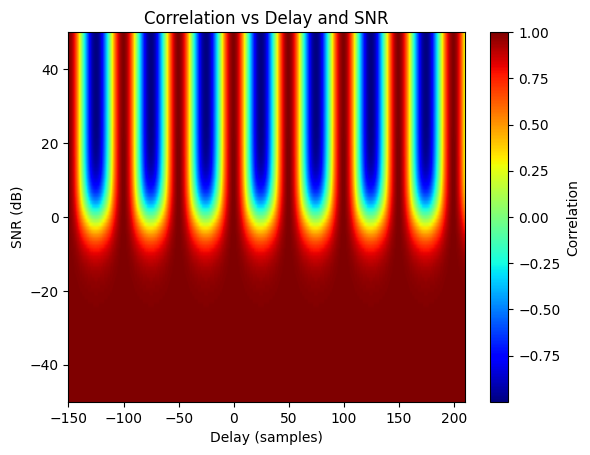

In [ ]:

def add_noise(signal, snr_db):
    signal_power = np.mean(signal ** 2)
    snr = 10 ** (snr_db / 10)
    noise_power = signal_power / snr
    np.random.seed(0)
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise

snr_range = np.linspace(-50, 50, 101)
cor_matrix = np.zeros((len(snr_range), len(delays)))

for i, snr in enumerate(snr_range):
    x_noisy = add_noise(x, snr)
    for j, t0 in enumerate(delays / fs):
        y = np.sin(2 * np.pi * f * (t - t0))
        y_noisy = add_noise(y, snr)
        cor_matrix[i, j] = my_corr(x_noisy, y_noisy)

plt.imshow(cor_matrix, aspect='auto', extent=[delays[0], delays[-1], snr_range[0], snr_range[-1]], origin='lower', cmap='jet')
plt.colorbar(label='Correlation')
plt.xlabel('Delay (samples)')
plt.ylabel('SNR (dB)')
plt.title('Correlation vs Delay and SNR')
plt.show()

Common source (alpha/beta)

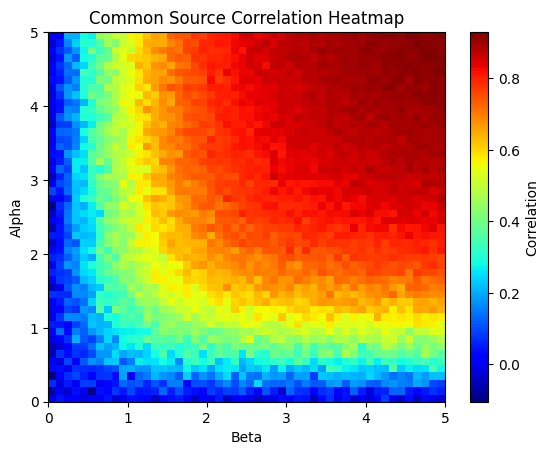

In [ ]:

def generate_common_source(alpha, beta, x):
    n1 = np.random.normal(0, 1, len(x))
    n2 = np.random.normal(0, 1, len(x))
    x1 = n1 + alpha * x
    x2 = n2 + beta * x
    return x1, x2

alphas = np.linspace(0, 5, 50)
betas = np.linspace(0, 5, 50)
common_corr = np.zeros((len(alphas), len(betas)))

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        x1, x2 = generate_common_source(alpha, beta, x)
        common_corr[i, j] = my_corr(x1, x2)

plt.imshow(common_corr, extent=[betas[0], betas[-1], alphas[0], alphas[-1]], origin='lower', aspect='auto', cmap='jet')
plt.colorbar(label='Correlation')
plt.xlabel('Beta')
plt.ylabel('Alpha')
plt.title('Common Source Correlation Heatmap')
plt.show()

#همنوایی فاز
Correlation vs. Delay

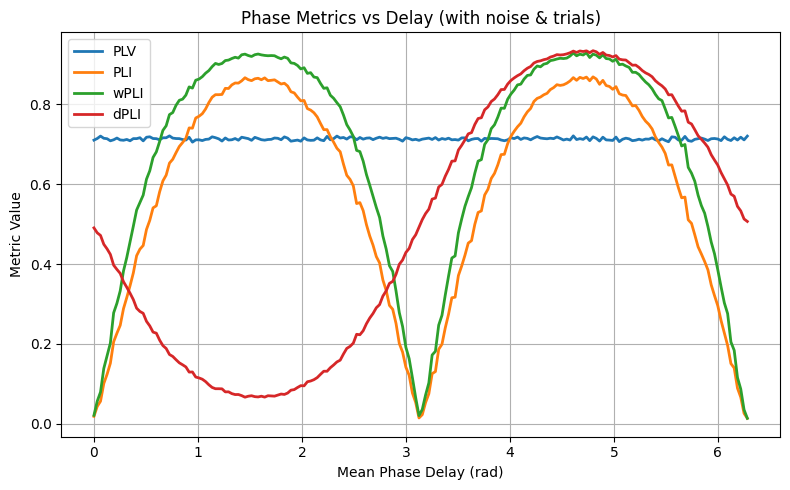

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# instant. phase
def phase(sig):
    return np.angle(hilbert(sig))

# wrapped difference
def dphi(x, y):
    return np.angle(np.exp(1j*(phase(x)-phase(y))))

# metrics
def PLV(d):   return np.abs(np.mean(np.exp(1j*d)))
def PLI(d):   return np.abs(np.mean(np.sign(np.sin(d))))
def wPLI(d):
    num = np.abs(np.mean(np.sin(d)))
    den = np.mean(np.abs(np.sin(d)))
    return num/den if den!=0 else 0
def dPLI(d):  return np.mean(d>0)

fs, f = 500, 10
t = np.arange(0, 1, 1/fs)

delays = np.linspace(0, 2*np.pi, 200)
plv, pli, wpli, dpli = [], [], [], []

n_trials = 50
noise_amp = 0.5

for d in delays:
    all_d = []
    for _ in range(n_trials):
        x = np.sin(2*np.pi*f*t) + noise_amp*np.random.randn(len(t))
        y = np.sin(2*np.pi*f*t + d) + noise_amp*np.random.randn(len(t))
        all_d.extend(dphi(x, y))
    all_d = np.array(all_d)
    plv.append( PLV(all_d) )
    pli.append( PLI(all_d) )
    wpli.append(wPLI(all_d))
    dpli.append(dPLI(all_d))

plt.figure(figsize=(8,5))
plt.plot(delays, plv,   label='PLV',  linewidth=2)
plt.plot(delays, pli,   label='PLI',  linewidth=2)
plt.plot(delays, wpli,  label='wPLI', linewidth=2)
plt.plot(delays, dpli,  label='dPLI', linewidth=2)
plt.xlabel('Mean Phase Delay (rad)')
plt.ylabel('Metric Value')
plt.title('Phase Metrics vs Delay (with noise & trials)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


SNR effect on correlation

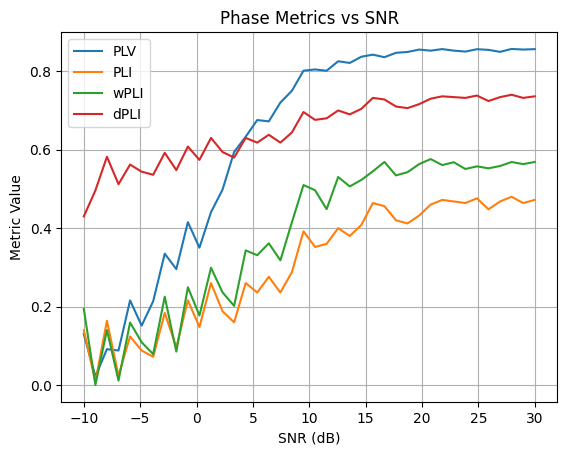

In [ ]:

def add_noise(signal, snr_db):
    power = np.mean(signal ** 2)
    noise_power = power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise


snr_values = np.linspace(-10, 30, 40)
plv_noise, pli_noise, wpli_noise, dpli_noise = [], [], [], []

for snr in snr_values:
    x_noisy = add_noise(x, snr)
    y_noisy = add_noise(np.sin(2 * np.pi * f * t + delay), snr)  # add a known delay
    plv_noise.append(compute_plv(x_noisy, y_noisy))
    pli_noise.append(compute_pli(x_noisy, y_noisy))
    wpli_noise.append(compute_wpli(x_noisy, y_noisy))
    dpli_noise.append(compute_dpli(x_noisy, y_noisy))


plt.figure()
plt.plot(snr_values, plv_noise, label='PLV')
plt.plot(snr_values, pli_noise, label='PLI')
plt.plot(snr_values, wpli_noise, label='wPLI')
plt.plot(snr_values, dpli_noise, label='dPLI')
plt.xlabel('SNR (dB)')
plt.ylabel('Metric Value')
plt.title('Phase Metrics vs SNR')
plt.legend()
plt.grid(True)
plt.show()



Common source (alpha/beta)

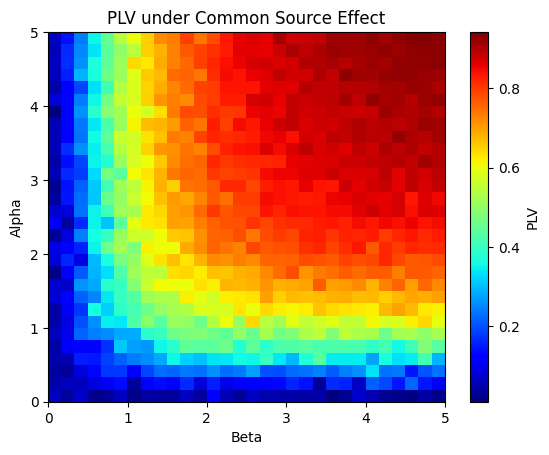

In [ ]:

alphas = np.linspace(0, 5, 30)
betas = np.linspace(0, 5, 30)
plv_common = np.zeros((len(alphas), len(betas)))

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        n1 = np.random.normal(0, 1, len(x))
        n2 = np.random.normal(0, 1, len(x))
        x1 = n1 + alpha * x
        x2 = n2 + beta * x
        plv_common[i, j] = compute_plv(x1, x2)


plt.figure()
plt.imshow(plv_common, extent=[betas[0], betas[-1], alphas[0], alphas[-1]],
           origin='lower', aspect='auto', cmap='jet')
plt.colorbar(label='PLV')
plt.xlabel('Beta')
plt.ylabel('Alpha')
plt.title('PLV under Common Source Effect')
plt.show()

In [43]:
!pip install networkx
!pip install scipy
!pip install requests
!pip install h5py



بخش دوم در نوت بوک دیگری آمده است.

لینکش را اینجا میگذارم . اما فایل هم جداگانه قرار داده شده است.

https://colab.research.google.com/drive/1Wv9jveaLMv0ue2gHedfOAurLeazugrB0?usp=sharing

#بخش سوم،روش های تحلیل گرافی ارتباطات مغزی
لطفا این کد را در جایی که دیتا را از قبل لود شده دارید ران کنید، متاسفانه اینجا نتوانستم درستش کنم.

In [45]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import networkx as nx

# 1. Load data
mat = scipy.io.loadmat('CA2_Data.mat')
adj_matrix     = mat['connections']       # binary adjacency
weight_matrix  = mat['weights']    # real-valued weights
raw_labels     = mat['labels'].flatten() # shape (32, 1) or (32,)
coordinates    = mat['coordinations']      # shape (2, N) or (N, 2)

# 2. Prepare labels list (uppercase) and helper for indexing
labels = [lab[0].upper() if isinstance(lab, np.ndarray) else lab.upper() for lab in raw_labels]

def find_label_index(query):
    q = query.upper()
    a, b = q.split('-')
    for i, lab in enumerate(labels):
        x, y = lab.split('-')
        if (x == a and y == b) or (x == b and y == a):
            return i
    raise KeyError(f"Label '{query}' not found in labels.")

# 3. Invalidate edges between nodes sharing any channel
n = len(labels)
node_ch = [tuple(lab.split('-')) for lab in labels]
valid_mask = np.ones((n, n), dtype=bool)
for i in range(n):
    for j in range(n):
        # invalidate if they share a channel
        if set(node_ch[i]) & set(node_ch[j]):
            valid_mask[i, j] = False

# 4. Threshold weight matrix to keep top percentile
threshold_percentile = 80  # e.g. keep top 20%
thr_val = np.percentile(weight_matrix.flatten(), threshold_percentile)
A_thresh = (weight_matrix >= thr_val).astype(int)

# 5. Apply invalidation mask
A_bin = A_thresh.copy()
W     = weight_matrix.copy()
A_bin[~valid_mask] = 0
W[~valid_mask]     = 0.0

# 6. Build graphs
G_bin = nx.from_numpy_array(A_bin)
G_wt  = nx.from_numpy_array(W)

# 7. Keep largest connected component for each graph
if not nx.is_connected(G_bin):
    comp = max(nx.connected_components(G_bin), key=len)
    G_bin = G_bin.subgraph(comp).copy()
if not nx.is_connected(G_wt):
    comp = max(nx.connected_components(G_wt), key=len)
    G_wt = G_wt.subgraph(comp).copy()

# 8. Compute metrics
# Degree Centrality (unweighted)
deg_cent = nx.degree_centrality(G_bin)
# Weighted Degree (sum of weights)
weighted_deg = dict(G_wt.degree(weight='weight'))
# Clustering Coefficient (average)
avg_clust = nx.average_clustering(G_bin)
# Betweenness Centrality (unweighted)
betw_cent = nx.betweenness_centrality(G_bin)
# Small-World Index function
def small_world_index(G, n_iter=100):
    C_real = nx.average_clustering(G)
    L_real = nx.average_shortest_path_length(G)
    n = G.number_of_nodes()
    p = nx.density(G)
    C_rand = L_rand = count = 0.0
    for _ in range(n_iter):
        Gr = nx.erdos_renyi_graph(n, p)
        if nx.is_connected(Gr):
            C_rand += nx.average_clustering(Gr)
            L_rand += nx.average_shortest_path_length(Gr)
            count += 1
    C_rand /= count
    L_rand /= count
    return (C_real / C_rand) / (L_real / L_rand)

sigma = small_world_index(G_bin)

# 9. Compute example shortest path between two labels
src = find_label_index('FZ-CZ')
tgt = find_label_index('CZ-PZ')
shortest_path = nx.shortest_path(G_bin, source=src, target=tgt)

# 10. Prepare node positions from coordinates
coords = np.array(coordinates)
if coords.shape[0] == 2:
    pos = {i: (coords[0, i], coords[1, i]) for i in range(coords.shape[1])}
else:
    pos = {i: (coords[i, 0], coords[i, 1]) for i in range(coords.shape[0])}

# 11. Plot all metrics
plt.figure(figsize=(15, 10))

# Degree Centrality
plt.subplot(2, 3, 1)
plt.bar(list(deg_cent.keys()), list(deg_cent.values()))
plt.title('Degree Centrality')
plt.xlabel('Node')
plt.ylabel('Centrality')

# Weighted Degree
plt.subplot(2, 3, 2)
nodes_w, vals_w = zip(*sorted(weighted_deg.items()))
plt.bar(nodes_w, vals_w)
plt.title('Weighted Degree')
plt.xlabel('Node')
plt.ylabel('Sum of Weights')

# Shortest Path
plt.subplot(2, 3, 3)
nx.draw(G_bin, pos, with_labels=True, node_color='lightblue', node_size=200)
path_edges = list(zip(shortest_path[:-1], shortest_path[1:]))
nx.draw_networkx_nodes(G_bin, pos, nodelist=shortest_path, node_color='red')
nx.draw_networkx_edges(G_bin, pos, edgelist=path_edges, edge_color='red', width=2)
plt.title(f'Shortest Path: {labels[src]} → {labels[tgt]}')

# Clustering Coefficient
plt.subplot(2, 3, 4)
plt.bar(['Avg Clustering'], [avg_clust])
plt.title('Average Clustering Coefficient')

# Betweenness Centrality
plt.subplot(2, 3, 5)
plt.bar(list(betw_cent.keys()), list(betw_cent.values()))
plt.title('Betweenness Centrality')
plt.xlabel('Node')


plt.subplot(2, 3, 6)
# Plot one bar at x=0
plt.bar(0, sigma)
# Label the x‑axis tick at 0 with your σ name
plt.xticks([0], ['Small‑World σ'])
plt.ylabel('σ value')
plt.title('Small‑World Index')


plt.tight_layout()
plt.show()

# 12. Print summary
print(f"Average clustering coefficient: {avg_clust:.4f}")
print(f"Small-World Index σ: {sigma:.4f}")
print(f"Shortest path {labels[src]} → {labels[tgt]}: {shortest_path}")



KeyError: 'adj_matrix'